# MATLAB vs Python Head-to-Head Comparison

This notebook loads intermediate checkpoint values exported from MATLAB (`Data/matlab_reference.mat`) and compares them step-by-step against the Python S2Sharp pipeline. Each checkpoint shows quantitative metrics (max absolute error, relative error) and difference heatmaps.

**Prerequisites:** Run `export_reference.m` in MATLAB first to generate the reference file.

In [1]:
import os
import numpy as np
import scipy.io
import h5py
import matplotlib.pyplot as plt

from s2sharp import s2sharp
from s2sharp.constants import (
    BAND_NAMES, DOWNSAMPLE_FACTORS, MTF, NUM_BANDS,
    DEFAULT_KERNEL_SIZE, DEFAULT_BORDER,
)
from s2sharp.preprocessing import normalize_data, compute_weights, create_subsampling
from s2sharp.convolution import (
    create_conv_kernel, create_conv_kernel_subspace, create_diff_kernels, conv_cm,
)
from s2sharp.initialization import initialize
from s2sharp.optimization import f_step
from s2sharp.solvers import z_step
from s2sharp.metrics import evaluate
from s2sharp.utils import conv2im, conv2mat, matlab_imresize

# --- Load dataset ---
data = scipy.io.loadmat('../Data/Aviris_cell_3.mat', squeeze_me=True, simplify_cells=True)
Yim = data['Yim']
bands = [Yim[i].astype(np.float64) for i in range(len(Yim))]
Xm_im = data['Xm_im'].astype(np.float64)

L = len(bands)
nl, nc = bands[1].shape  # B2 is 10m reference
n = nl * nc
print(f"Dataset: {L} bands, 10m size = ({nl}, {nc}), n = {n}")
print(f"Ground truth shape: {Xm_im.shape}")

# --- Load MATLAB reference (v7.3 / HDF5 format) ---
ref_path = '../Data/matlab_reference.mat'
HAS_REF = os.path.exists(ref_path)

if HAS_REF:
    def load_hdf5_ref(path):
        """Load MATLAB v7.3 .mat file via h5py.

        MATLAB HDF5 stores arrays in column-major (Fortran) order,
        so we need to transpose to match Python (row-major/C) layout.
        Complex arrays are stored as structured dtypes with 'real'/'imag' fields.
        """
        out = {}
        with h5py.File(path, 'r') as f:
            for key in f.keys():
                if key.startswith('#'):
                    continue
                val = f[key][()]

                if isinstance(val, np.ndarray):
                    # Handle complex structured dtype: ('real','imag')
                    if val.dtype.names and 'real' in val.dtype.names:
                        val = val['real'] + 1j * val['imag']

                    # Transpose to convert from MATLAB column-major to Python row-major
                    # For 3D: MATLAB (L, nc, nl) in HDF5 â†’ Python (nl, nc, L)
                    if val.ndim == 3:
                        val = val.transpose(2, 1, 0)
                    elif val.ndim == 2:
                        val = val.T

                    # Squeeze to scalar
                    val = np.squeeze(val)
                    if val.ndim == 0:
                        val = float(val.real)

                out[key] = val
        return out

    ref = load_hdf5_ref(ref_path)
    print(f"\nMATLAB reference loaded. Keys: {sorted(ref.keys())}")
    # Show shapes for verification
    for k in sorted(ref.keys()):
        v = ref[k]
        if isinstance(v, np.ndarray):
            print(f"  {k}: shape={v.shape} dtype={v.dtype}")
        else:
            print(f"  {k}: {v}")
else:
    ref = None
    print("\n*** matlab_reference.mat not found! ***")
    print("Run export_reference.m in MATLAB first to generate it.")
    print("Comparisons will be skipped; Python-only results shown.")

Dataset: 12 bands, 10m size = (408, 408), n = 166464
Ground truth shape: (408, 408, 12)

MATLAB reference loaded. Keys: ['ERGAS_20m_final', 'ERGAS_60m_final', 'FBM2', 'F_init', 'F_iter1', 'L', 'Mask', 'RMSE_final', 'SAMm_2m_final', 'SAMm_final', 'SRE_final', 'SSIM_final', 'W', 'Y', 'Ylim', 'Z_iter1', 'aSSIM_final', 'av', 'd', 'lambda', 'nc', 'nl', 'q', 'r', 'sdf']
  ERGAS_20m_final: 1.3155656688200352
  ERGAS_60m_final: 0.45308697366056655
  FBM2: shape=(408, 408, 12) dtype=complex128
  F_init: shape=(12, 8) dtype=float64
  F_iter1: shape=(12, 8) dtype=float64
  L: 12.0
  Mask: shape=(12, 166464) dtype=float64
  RMSE_final: 0.41011821332288273
  SAMm_2m_final: 0.8736926557889862
  SAMm_final: 0.8717398673798674
  SRE_final: shape=(12,) dtype=float64
  SSIM_final: shape=(12,) dtype=float64
  W: shape=(166464,) dtype=float64
  Y: shape=(12, 166464) dtype=float64
  Ylim: shape=(408, 408, 12) dtype=float64
  Z_iter1: shape=(8, 166464) dtype=float64
  aSSIM_final: 0.9584595250029291
  av: s

In [2]:
# ============================================================
# Helper functions
# ============================================================
results_log = []  # (name, max_err, rel_err, passed)


def compare(name, py, mat, tol=1e-10):
    """Print max abs error, relative error, and PASS/FAIL."""
    py = np.asarray(py, dtype=np.float64).ravel()
    mat = np.asarray(mat, dtype=np.float64).ravel()
    assert py.shape == mat.shape, f"Shape mismatch: {py.shape} vs {mat.shape}"
    diff = np.abs(py - mat)
    max_err = diff.max()
    denom = np.abs(mat).max()
    rel_err = max_err / denom if denom > 0 else max_err
    passed = max_err <= tol
    status = "PASS" if passed else "FAIL"
    print(f"  {name:30s}  max|err|={max_err:.3e}  rel={rel_err:.3e}  [{status}]")
    results_log.append((name, max_err, rel_err, passed))
    return passed


def compare_sign_aligned(name, py, mat, tol=1e-10):
    """Compare matrices that may differ by column sign (SVD ambiguity)."""
    py = np.asarray(py, dtype=np.float64)
    mat = np.asarray(mat, dtype=np.float64)
    # Align signs: flip Python columns to match MATLAB
    for col in range(py.shape[1]):
        if np.dot(py[:, col], mat[:, col]) < 0:
            py[:, col] *= -1
    return compare(name, py, mat, tol)


def reorder_ref(mat_data, nl, nc):
    """Convert MATLAB column-major pixel ordering to Python row-major."""
    if mat_data.ndim == 1:
        return mat_data.reshape(nl, nc, order='F').ravel()
    result = np.zeros_like(mat_data)
    for i in range(mat_data.shape[0]):
        result[i] = mat_data[i].reshape(nl, nc, order='F').ravel()
    return result


def plot_diff(name, py_2d, mat_2d, band_label=""):
    """Side-by-side images + difference heatmap."""
    py_2d = np.asarray(py_2d, dtype=np.float64)
    mat_2d = np.asarray(mat_2d, dtype=np.float64)
    diff = py_2d - mat_2d

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    vmin = min(py_2d.min(), mat_2d.min())
    vmax = max(py_2d.max(), mat_2d.max())

    axes[0].imshow(mat_2d, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'MATLAB {band_label}')
    axes[0].axis('off')

    axes[1].imshow(py_2d, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Python {band_label}')
    axes[1].axis('off')

    im = axes[2].imshow(diff, cmap='RdBu_r')
    axes[2].set_title(f'Difference (Py - MAT)')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    fig.suptitle(name, fontsize=13)
    plt.tight_layout()
    plt.show()

## Checkpoint 1 â€” Data Normalization & Parameters

In [3]:
# Normalize data
bands_norm, av = normalize_data(bands)

# Compute sdf
d = DOWNSAMPLE_FACTORS.copy()
mtf = MTF.copy()
sdf = d * np.sqrt(-2 * np.log(mtf) / np.pi**2)
sdf[d == 1] = 0

# Parameters matching export_reference.m
r = 8
lam = 1.8998e-04
q = np.array([1, 0.3851, 6.9039, 19.9581, 47.8967, 27.5518, 2.7100, 34.8689])
ni = 10
limsub = DEFAULT_BORDER  # 2
dx, dy = DEFAULT_KERNEL_SIZE  # (12, 12)

print(f"r={r}, lambda={lam}, CDiter={ni}")
print(f"q = {q}")
print(f"nl={nl}, nc={nc}, L={L}, n={n}")

if HAS_REF:
    print("\n--- Comparison ---")
    compare('av (normalization)', av, ref['av'], tol=1e-6)
    compare('sdf (blur std)', sdf, ref['sdf'])
else:
    print(f"\nav = {av}")
    print(f"sdf = {sdf}")

r=8, lambda=0.00018998, CDiter=10
q = [ 1.      0.3851  6.9039 19.9581 47.8967 27.5518  2.71   34.8689]
nl=408, nc=408, L=12, n=166464

--- Comparison ---
  av (normalization)              max|err|=1.770e-08  rel=1.347e-15  [PASS]
  sdf (blur std)                  max|err|=0.000e+00  rel=0.000e+00  [PASS]


## Checkpoint 2 â€” Subspace Blur Kernels (FBM2)

Tests `create_conv_kernel_subspace()` â€” Phase 1 rounding fix.

FBM2 shape: (408, 408, 12), dtype: complex128
MATLAB FBM2 shape: (408, 408, 12)

--- Comparison ---
  FBM2 (real part)                max|err|=5.551e-16  rel=5.551e-16  [PASS]
  FBM2 (imag part)                max|err|=1.971e-16  rel=1.284e+00  [PASS]


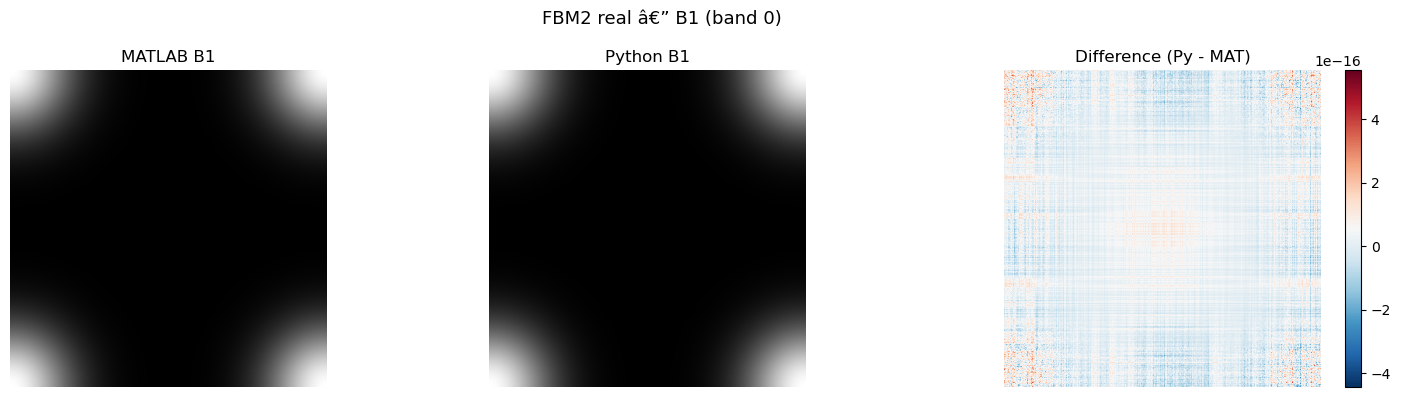

In [4]:
FBM2 = create_conv_kernel_subspace(sdf, nl, nc, L, dx, dy)
print(f"FBM2 shape: {FBM2.shape}, dtype: {FBM2.dtype}")

if HAS_REF:
    ref_FBM2 = ref['FBM2']
    print(f"MATLAB FBM2 shape: {ref_FBM2.shape}")
    print("\n--- Comparison ---")
    compare('FBM2 (real part)', FBM2.real, ref_FBM2.real, tol=1e-10)
    compare('FBM2 (imag part)', FBM2.imag, ref_FBM2.imag, tol=1e-10)

    # Difference heatmap for band 0 (B1, 60m, largest complementary blur)
    plot_diff('FBM2 real â€” B1 (band 0)', FBM2[:, :, 0].real, ref_FBM2[:, :, 0].real, 'B1')

## Checkpoint 3 â€” Upsampled Bands (Ylim)

Tests `matlab_imresize()` â€” Phase 2 interpolation fix.

Ylim shape: (408, 408, 12)
MATLAB Ylim shape: (408, 408, 12)

--- Comparison ---
  Ylim (all bands)                max|err|=2.176e-14  rel=5.030e-15  [PASS]
    Ylim band 0 (B1, d=6)         max|err|=2.176e-14  rel=5.483e-15  [PASS]
    Ylim band 4 (B5, d=2)         max|err|=2.220e-15  rel=1.029e-15  [PASS]
    Ylim band 5 (B6, d=2)         max|err|=1.998e-15  rel=1.031e-15  [PASS]
    Ylim band 6 (B7, d=2)         max|err|=1.998e-15  rel=9.072e-16  [PASS]
    Ylim band 8 (B8A, d=2)        max|err|=1.998e-15  rel=9.324e-16  [PASS]
    Ylim band 9 (B9, d=6)         max|err|=9.215e-15  rel=5.139e-15  [PASS]
    Ylim band 10 (B11, d=2)       max|err|=1.998e-15  rel=8.782e-16  [PASS]
    Ylim band 11 (B12, d=2)       max|err|=6.661e-15  rel=2.076e-15  [PASS]


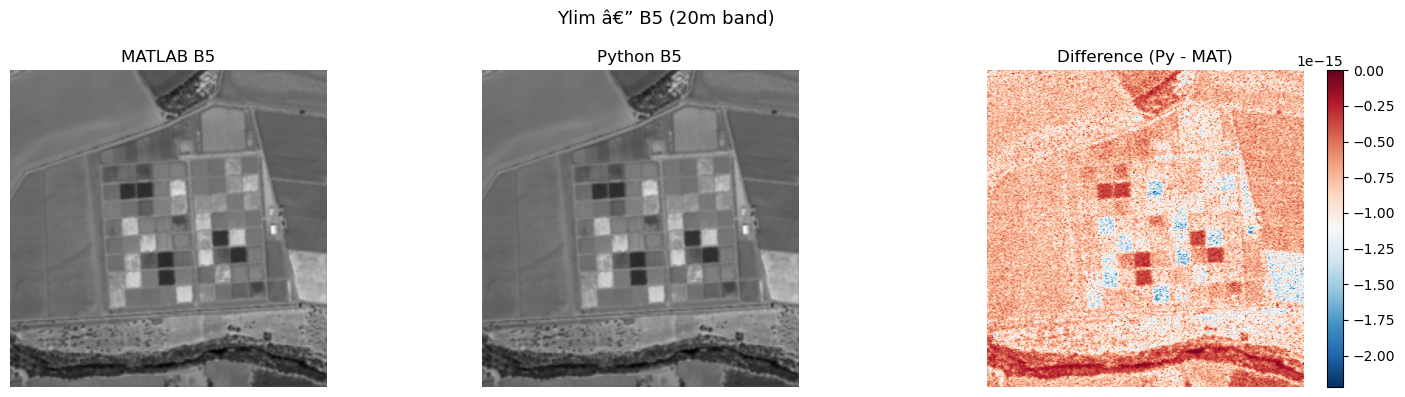

In [5]:
Ylim = np.zeros((nl, nc, L))
for i in range(L):
    di = d[i]
    if di == 1:
        Ylim[:, :, i] = bands_norm[i]
    else:
        Ylim[:, :, i] = matlab_imresize(bands_norm[i], di)

print(f"Ylim shape: {Ylim.shape}")

if HAS_REF:
    ref_Ylim = ref['Ylim']
    print(f"MATLAB Ylim shape: {ref_Ylim.shape}")
    print("\n--- Comparison ---")
    compare('Ylim (all bands)', Ylim, ref_Ylim, tol=1e-10)

    # Per-band breakdown for non-10m bands
    for i in range(L):
        if d[i] > 1:
            compare(f'  Ylim band {i} ({BAND_NAMES[i]}, d={d[i]})',
                    Ylim[:, :, i], ref_Ylim[:, :, i], tol=1e-10)

    # Heatmap for B5 (index 4, 20m band)
    plot_diff('Ylim â€” B5 (20m band)', Ylim[:, :, 4], ref_Ylim[:, :, 4], 'B5')

## Checkpoint 4 â€” Initial Subspace F_init (SVD)

F_init shape: (12, 8)
MATLAB F_init shape: (12, 8)

--- Comparison (sign-aligned) ---
  F_init (SVD subspace)           max|err|=1.298e-13  rel=1.680e-13  [PASS]


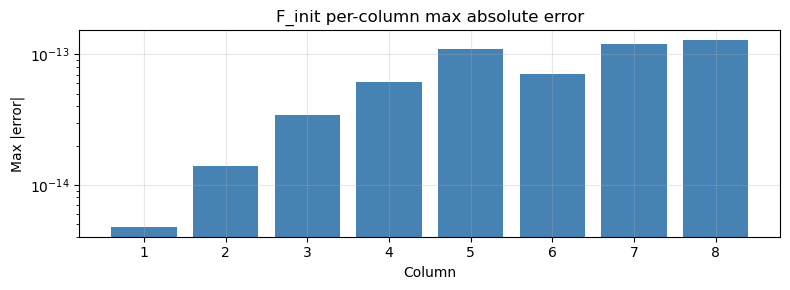

In [6]:
# Full initialization pipeline
Y, M, F = initialize(bands_norm, sdf, nl, nc, L, dx, dy, d, limsub, r)

# Also compute F_init separately to match MATLAB checkpoint
Y2im = np.real(np.fft.ifft2(np.fft.fft2(Ylim, axes=(0, 1)) * FBM2, axes=(0, 1)))
Y2tr = Y2im[limsub:-limsub, limsub:-limsub, :]
nl_crop = nl - 2 * limsub
nc_crop = nc - 2 * limsub
Y2n = Y2tr.reshape(nl_crop * nc_crop, L)
F_full, _, _ = np.linalg.svd(Y2n.T, full_matrices=False)
F_init = F_full[:, :r]

print(f"F_init shape: {F_init.shape}")

if HAS_REF:
    ref_F_init = ref['F_init']
    print(f"MATLAB F_init shape: {ref_F_init.shape}")
    print("\n--- Comparison (sign-aligned) ---")
    compare_sign_aligned('F_init (SVD subspace)', F_init.copy(), ref_F_init.copy(), tol=1e-10)

    # Per-column max error bar chart
    F_aligned = F_init.copy()
    for col in range(r):
        if np.dot(F_aligned[:, col], ref_F_init[:, col]) < 0:
            F_aligned[:, col] *= -1
    col_errors = [np.abs(F_aligned[:, c] - ref_F_init[:, c]).max() for c in range(r)]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(range(1, r + 1), col_errors, color='steelblue')
    ax.set_xlabel('Column')
    ax.set_ylabel('Max |error|')
    ax.set_title('F_init per-column max absolute error')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Sign-align F to MATLAB convention for consistent downstream comparisons
    for col in range(F.shape[1]):
        if np.dot(F[:, col], ref_F_init[:, col]) < 0:
            F[:, col] *= -1

## Checkpoint 5 â€” Observed Data Y and Mask

In [7]:
Mask = M.reshape(n, L).T  # (L, n)

print(f"Y shape: {Y.shape}, Mask shape: {Mask.shape}")

if HAS_REF:
    ref_Y = reorder_ref(ref['Y'], nl, nc)
    ref_Mask = reorder_ref(ref['Mask'], nl, nc)
    print(f"MATLAB Y shape: {ref_Y.shape}, Mask shape: {ref_Mask.shape}")
    print("\n--- Comparison ---")
    compare('Y (observed data)', Y, ref_Y, tol=1e-10)
    compare('Mask (subsampling)', Mask, ref_Mask, tol=0)

Y shape: (12, 166464), Mask shape: (12, 166464)
MATLAB Y shape: (12, 166464), Mask shape: (12, 166464)

--- Comparison ---
  Y (observed data)               max|err|=5.773e-15  rel=1.335e-15  [PASS]
  Mask (subsampling)              max|err|=0.000e+00  rel=0.000e+00  [PASS]


## Checkpoint 6 â€” Adaptive Weights W

Tests `compute_weights()` â€” Phase 4 boundary condition fix.

W shape: (408, 408, 1), range: [0.5000, 1.0000]
MATLAB W size: 166464

--- Comparison ---
  W (weights)                     max|err|=9.992e-16  rel=9.992e-16  [PASS]


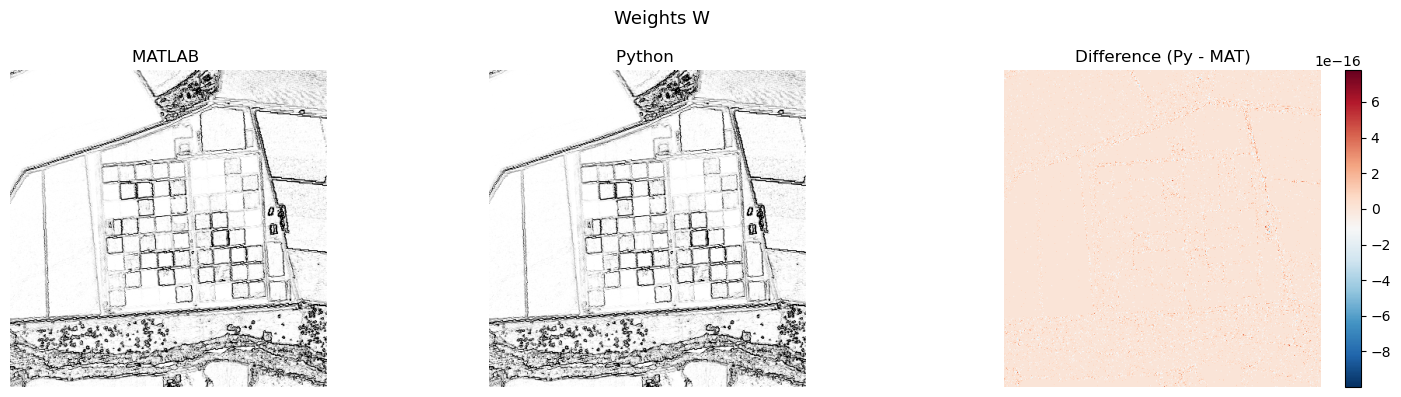

In [8]:
sigmas = 1.0
W = compute_weights(Y, d, sigmas, nl)
print(f"W shape: {W.shape}, range: [{W.min():.4f}, {W.max():.4f}]")

if HAS_REF:
    ref_W = reorder_ref(ref['W'].reshape(1, -1), nl, nc).ravel()
    print(f"MATLAB W size: {ref_W.size}")
    print("\n--- Comparison ---")
    compare('W (weights)', W, ref_W, tol=1e-10)

    # Difference heatmap
    plot_diff('Weights W', W.reshape(nl, nc), ref_W.reshape(nl, nc))

## Checkpoint 7 â€” Z after first iteration (Z-step)

In [9]:
# Build convolution kernels
FBM = create_conv_kernel(sdf, d, nl, nc, L, dx, dy)
FDH, FDV, FDHC, FDVC = create_diff_kernels(nl, nc, r)

# Z-step from zero initialization
Z = np.zeros((r, n))
Z, cg_iters = z_step(Y, FBM, F, lam, nl, nc, Z, Mask, q, FDH, FDV, FDHC, FDVC, W)
Z_iter1 = Z.copy()

print(f"Z_iter1 shape: {Z_iter1.shape}")
print(f"Z_iter1 range: [{Z_iter1.min():.6f}, {Z_iter1.max():.6f}]")
print(f"CG iterations: {cg_iters}")

if HAS_REF:
    ref_Z = reorder_ref(ref['Z_iter1'], nl, nc)
    print(f"MATLAB Z_iter1 shape: {ref_Z.shape}")
    print("\n--- Comparison ---")
    compare('Z_iter1 (after first Z-step)', Z_iter1, ref_Z, tol=1e-6)

Z_iter1 shape: (8, 166464)
Z_iter1 range: [-9.045589, 4.036832]
CG iterations: 24
MATLAB Z_iter1 shape: (8, 166464)

--- Comparison ---
  Z_iter1 (after first Z-step)    max|err|=1.766e-13  rel=1.952e-14  [PASS]


## Checkpoint 8 â€” F after first iteration (F-step)

Tests `f_step()` â€” Phase 3 optimizer fix.

In [10]:
F1 = f_step(F, Z, Y, FBM, nl, nc, Mask)
F_iter1 = F1.copy()

print(f"F_iter1 shape: {F_iter1.shape}")

if HAS_REF:
    ref_F1 = ref['F_iter1']
    print(f"MATLAB F_iter1 shape: {ref_F1.shape}")
    print("\n--- Comparison (sign-aligned) ---")
    compare_sign_aligned('F_iter1 (after first F-step)', F_iter1.copy(), ref_F1.copy(), tol=1e-6)

F_iter1 shape: (12, 8)
MATLAB F_iter1 shape: (12, 8)

--- Comparison (sign-aligned) ---
  F_iter1 (after first F-step)    max|err|=5.474e-06  rel=7.050e-06  [FAIL]


## Checkpoint 9 â€” Full Run & Final Metrics

Run full `s2sharp()` with 10 iterations and compare final metrics.
Tests Phase 5 SSIM fix.

Completed in 106.3 s
Output image shape: (404, 404, 12)

Python final metrics:
  SAM:       0.871740
  aSSIM:     0.990806
  RMSE:      0.410118
  ERGAS_20m: 1.315567
  ERGAS_60m: 0.453087

MATLAB final metrics:
  SAM:       0.871740
  aSSIM:     0.958460
  RMSE:      0.410118
  ERGAS_20m: 1.315566
  ERGAS_60m: 0.453087

--- Metric Comparison ---
  SAM                             max|err|=1.309e-07  rel=1.502e-07  [PASS]
  aSSIM                           max|err|=3.235e-02  rel=3.375e-02  [FAIL]
  RMSE                            max|err|=3.659e-07  rel=8.922e-07  [PASS]
  ERGAS_20m                       max|err|=1.652e-06  rel=1.255e-06  [PASS]
  ERGAS_60m                       max|err|=1.221e-07  rel=2.696e-07  [PASS]
  SRE (all bands)                 max|err|=2.807e-03  rel=4.215e-05  [FAIL]


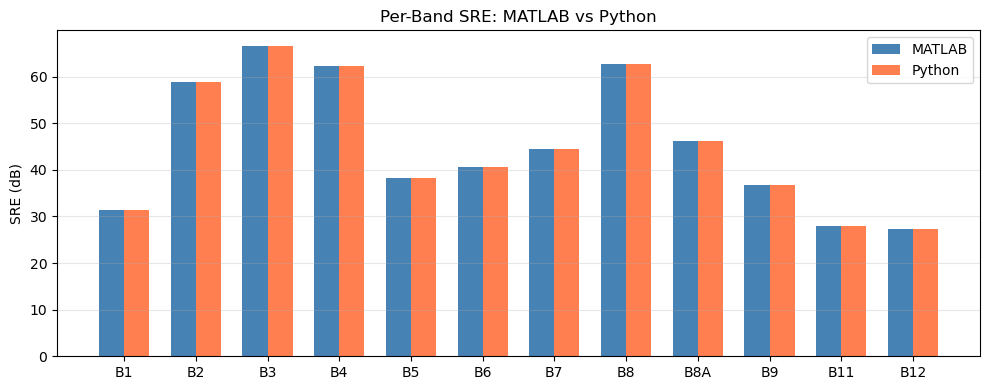

In [11]:
result = s2sharp(
    bands,
    ground_truth=Xm_im,
    r=r,
    lam=lam,
    q=q,
    cd_iter=ni,
)

print(f"Completed in {result.Time:.1f} s")
print(f"Output image shape: {result.image.shape}")

# Final metrics
py_SAM = result.SAMm[-1]
py_aSSIM = result.aSSIM[-1]
py_RMSE = result.RMSE[-1]
py_ERGAS_20m = result.ERGAS_20m[-1]
py_ERGAS_60m = result.ERGAS_60m[-1]
py_SRE = result.SRE[-1]

print(f"\nPython final metrics:")
print(f"  SAM:       {py_SAM:.6f}")
print(f"  aSSIM:     {py_aSSIM:.6f}")
print(f"  RMSE:      {py_RMSE:.6f}")
print(f"  ERGAS_20m: {py_ERGAS_20m:.6f}")
print(f"  ERGAS_60m: {py_ERGAS_60m:.6f}")

if HAS_REF:
    mat_SAM = float(ref['SAMm_final'])
    mat_aSSIM = float(ref['aSSIM_final'])
    mat_RMSE = float(ref['RMSE_final'])
    mat_ERGAS_20m = float(ref['ERGAS_20m_final'])
    mat_ERGAS_60m = float(ref['ERGAS_60m_final'])
    mat_SRE = np.asarray(ref['SRE_final']).ravel()

    print(f"\nMATLAB final metrics:")
    print(f"  SAM:       {mat_SAM:.6f}")
    print(f"  aSSIM:     {mat_aSSIM:.6f}")
    print(f"  RMSE:      {mat_RMSE:.6f}")
    print(f"  ERGAS_20m: {mat_ERGAS_20m:.6f}")
    print(f"  ERGAS_60m: {mat_ERGAS_60m:.6f}")

    print("\n--- Metric Comparison ---")
    metrics_tol = 1e-4
    compare('SAM', py_SAM, mat_SAM, tol=metrics_tol)
    compare('aSSIM', py_aSSIM, mat_aSSIM, tol=metrics_tol)
    compare('RMSE', py_RMSE, mat_RMSE, tol=metrics_tol)
    compare('ERGAS_20m', py_ERGAS_20m, mat_ERGAS_20m, tol=metrics_tol)
    if not np.isnan(mat_ERGAS_60m):
        compare('ERGAS_60m', py_ERGAS_60m, mat_ERGAS_60m, tol=metrics_tol)
    compare('SRE (all bands)', py_SRE, mat_SRE, tol=metrics_tol)

    # Per-band SRE bar chart: Python vs MATLAB
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(mat_SRE))
    width = 0.35
    band_labels = [BAND_NAMES[i] for i in range(len(mat_SRE))]
    ax.bar(x - width / 2, mat_SRE, width, label='MATLAB', color='steelblue')
    ax.bar(x + width / 2, py_SRE[:len(mat_SRE)], width, label='Python', color='coral')
    ax.set_ylabel('SRE (dB)')
    ax.set_title('Per-Band SRE: MATLAB vs Python')
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Summary

All checkpoint results at a glance.

In [12]:
if HAS_REF and results_log:
    print(f"{'Checkpoint':<40s}  {'Max |err|':>12s}  {'Rel err':>12s}  {'Status':>6s}")
    print("-" * 76)
    all_pass = True
    for name, max_err, rel_err, passed in results_log:
        status = "PASS" if passed else "FAIL"
        print(f"{name:<40s}  {max_err:12.3e}  {rel_err:12.3e}  {status:>6s}")
        if not passed:
            all_pass = False
    print("-" * 76)
    n_pass = sum(1 for _, _, _, p in results_log if p)
    n_total = len(results_log)
    print(f"\nResult: {n_pass}/{n_total} checks passed.")
    if all_pass:
        print("All checkpoints PASS â€” Python matches MATLAB!")
    else:
        print("Some checkpoints FAILED â€” investigate differences above.")
else:
    print("No MATLAB reference data available. Run export_reference.m first.")

Checkpoint                                   Max |err|       Rel err  Status
----------------------------------------------------------------------------
av (normalization)                           1.770e-08     1.347e-15    PASS
sdf (blur std)                               0.000e+00     0.000e+00    PASS
FBM2 (real part)                             5.551e-16     5.551e-16    PASS
FBM2 (imag part)                             1.971e-16     1.284e+00    PASS
Ylim (all bands)                             2.176e-14     5.030e-15    PASS
  Ylim band 0 (B1, d=6)                      2.176e-14     5.483e-15    PASS
  Ylim band 4 (B5, d=2)                      2.220e-15     1.029e-15    PASS
  Ylim band 5 (B6, d=2)                      1.998e-15     1.031e-15    PASS
  Ylim band 6 (B7, d=2)                      1.998e-15     9.072e-16    PASS
  Ylim band 8 (B8A, d=2)                     1.998e-15     9.324e-16    PASS
  Ylim band 9 (B9, d=6)                      9.215e-15     5.139e-15    PASS